# Feedforward weight and sparsity structure

This notebook visualizes the frozen weights and biases in executable
feedforward translations of a multivariate polynomial basis emulator.
The model is a branched modular graph, not one monolithic dense matrix, so
the plots retain layer and multiplier-node boundaries.

Signed-log heatmaps reveal coefficient magnitude and sign; binary masks
show exact sparsity independently of scale. Analytically zero roots are
canonicalized from roundoff-scale values to exact zeros in the converted
copy. Root-shift biases and final
normalization weights are displayed separately from multiplier blocks.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib import colors
from torch import nn

from neural_polynomial_emulation import (
    FeedforwardProductNet,
    MultivariateBasisEmulator,
    emulator_complexity,
    multi_index_set,
    to_feedforward,
)

DIMENSION = 2
ORDER = 4
FAMILY = "legendre"
INDEX_SET_TYPE = "total_degree"
RELU_DEPTH = 12
TANH_TOLERANCE = 1e-6
DTYPE = torch.float64
PRODUCTS = ("relu", "tanh", "repu2")
FLATTEN_AFFINE_LAYERS = False
SHOW_XRAY_3D = True
XRAY_PARAMETER_CLASSES = {"relu": 0, "tanh": 0, "repu2": 0}
PARAMETER_PALETTE = "inspection"

multi_index = multi_index_set(DIMENSION, ORDER, INDEX_SET_TYPE)
models = {}
for product in PRODUCTS:
    functional = MultivariateBasisEmulator(
        multi_index,
        family=FAMILY,
        product=product,
        num_layers=RELU_DEPTH,
        tanh_tolerance=TANH_TOLERANCE,
    )
    models[product] = to_feedforward(functional, dtype=DTYPE)


In [2]:
def signed_log(values):
    return np.sign(values) * np.log10(1.0 + np.abs(values))


FIGURE_BACKGROUND = "#071018"
FIGURE_INK = "#dbe9f4"


def parameter_colormap():
    if PARAMETER_PALETTE == "inspection":
        return colors.LinearSegmentedColormap.from_list(
            "inspection_xray",
            [
                (0.00, "#33206f"),
                (0.18, "#5558c9"),
                (0.36, "#38b8dc"),
                (0.50, "#100c2e"),
                (0.64, "#62d7a1"),
                (0.82, "#c7df55"),
                (1.00, "#ee9732"),
            ],
        )
    if PARAMETER_PALETTE == "electronics":
        return colors.LinearSegmentedColormap.from_list(
            "electronics_xray",
            ["#0646a5", "#43d9ff", "#071018", "#ff8a1f", "#ffe66d"],
        )
    return plt.get_cmap(PARAMETER_PALETTE)


def sparsity_colormap():
    return colors.ListedColormap([FIGURE_BACKGROUND, "#c7df55"])


def style_inspection_axis(ax):
    ax.set_facecolor(FIGURE_BACKGROUND)
    ax.tick_params(colors=FIGURE_INK)
    ax.xaxis.label.set_color(FIGURE_INK)
    ax.yaxis.label.set_color(FIGURE_INK)
    ax.title.set_color(FIGURE_INK)
    for spine in ax.spines.values():
        spine.set_color("#527487")


def style_inspection_colorbar(colorbar):
    colorbar.ax.tick_params(colors=FIGURE_INK)
    colorbar.ax.yaxis.label.set_color(FIGURE_INK)
    colorbar.outline.set_edgecolor("#527487")


def short_name(name, limit=68):
    return name if len(name) <= limit else "..." + name[-(limit - 3):]


def linear_records(model):
    records = []
    for name, layer in model.named_modules():
        if not isinstance(layer, nn.Linear):
            continue
        weight = layer.weight.detach().cpu().numpy()
        bias = layer.bias.detach().cpu().numpy()
        records.append(
            {
                "name": name,
                "weight": weight,
                "bias": bias,
                "vector": np.concatenate((weight.ravel(), bias.ravel())),
            }
        )
    return records


def padded_atlas(records):
    width = max(record["vector"].size for record in records)
    atlas = np.full((len(records), width), np.nan)
    for row, record in enumerate(records):
        vector = record["vector"]
        atlas[row, : vector.size] = vector
    return atlas


def grouped_product_networks(model):
    groups = []
    for name, module in model.named_modules():
        if not isinstance(module, FeedforwardProductNet):
            continue
        layers = [
            layer for layer in module.network if isinstance(layer, nn.Linear)
        ]
        vector = np.concatenate(
            [parameter.detach().cpu().numpy().ravel() for parameter in module.parameters()]
        )
        match = next(
            (group for group in groups if np.array_equal(group["vector"], vector)),
            None,
        )
        if match is None:
            groups.append({"names": [name], "layers": layers, "vector": vector})
        else:
            match["names"].append(name)
    return groups


def plot_native_gallery(product, model, *, nonzero_mask):
    groups = grouped_product_networks(model)
    columns = max(len(group["layers"]) for group in groups)
    figure_width = max(9, 1.55 * columns)
    figure_height = max(2.8, 1.45 * len(groups))
    fig, axes = plt.subplots(
        len(groups), columns,
        figsize=(figure_width, figure_height),
        squeeze=False,
    )
    fig.patch.set_facecolor(FIGURE_BACKGROUND)
    fig.subplots_adjust(
        left=0.06,
        right=0.98 if nonzero_mask else 0.93,
        bottom=0.04,
        top=0.90,
        wspace=0.08,
        hspace=0.12,
    )
    coefficient_colormap = parameter_colormap()
    mask_colormap = sparsity_colormap()
    transformed_matrices = [
        signed_log(
            np.column_stack(
                (layer.weight.detach().cpu().numpy(), layer.bias.detach().cpu().numpy())
            )
        )
        for group in groups
        for layer in group["layers"]
    ]
    limit = max(max(np.max(np.abs(matrix)) for matrix in transformed_matrices), 1e-15)
    image = None
    for row, group in enumerate(groups):
        for column, layer in enumerate(group["layers"]):
            augmented = np.column_stack(
                (layer.weight.detach().cpu().numpy(), layer.bias.detach().cpu().numpy())
            )
            if nonzero_mask:
                displayed = augmented != 0.0
                image = axes[row, column].imshow(
                    displayed,
                    cmap=mask_colormap,
                    vmin=0,
                    vmax=1,
                    interpolation="nearest",
                )
            else:
                displayed = signed_log(augmented)
                image = axes[row, column].imshow(
                    displayed,
                    cmap=coefficient_colormap,
                    vmin=-limit,
                    vmax=limit,
                    interpolation="nearest",
                )
            axes[row, column].axvline(
                layer.weight.shape[1] - 0.5, color="#f1f7f9", linewidth=0.5
            )
            axes[row, column].set_aspect("equal")
            axes[row, column].set_xticks([])
            axes[row, column].set_yticks([])
            if row == 0:
                axes[row, column].set_title(f"layer {column}", fontsize=8)
            style_inspection_axis(axes[row, column])
        for column in range(len(group["layers"]), columns):
            axes[row, column].axis("off")
        axes[row, 0].set_ylabel(
            f"class {row}\n×{len(group['names'])}",
            rotation=0,
            ha="right",
            va="center",
            fontsize=8,
        )
    kind = "exact nonzero masks" if nonzero_mask else "signed-log coefficients"
    fig.suptitle(
        f"{product}: native [W | b] multiplier matrices — {kind}",
        color=FIGURE_INK,
        fontsize=13,
    )
    if not nonzero_mask:
        colorbar = fig.colorbar(
            image, ax=axes, shrink=0.55, label=r"sign$(\theta)\log_{10}(1+|\theta|)$"
        )
        style_inspection_colorbar(colorbar)
    plt.show()


def draw_xray(ax, product, model, class_index):
    groups = grouped_product_networks(model)
    if not 0 <= class_index < len(groups):
        raise ValueError(
            f"{product} has {len(groups)} parameter classes; got {class_index}"
        )
    group = groups[class_index]
    matrices = [
        np.column_stack(
            (layer.weight.detach().cpu().numpy(), layer.bias.detach().cpu().numpy())
        )
        for layer in group["layers"]
    ]
    transformed = [signed_log(matrix) for matrix in matrices]
    limit = max(max(np.max(np.abs(matrix)) for matrix in transformed), 1e-15)
    normalization = colors.Normalize(vmin=-limit, vmax=limit)
    colormap = parameter_colormap()
    max_rows = max(matrix.shape[0] for matrix in matrices)
    max_columns = max(matrix.shape[1] for matrix in matrices)

    for depth, (layer, matrix, transformed_matrix) in enumerate(
        zip(group["layers"], matrices, transformed, strict=True)
    ):
        rows, columns = matrix.shape
        x_offset = (max_columns - columns) / 2
        y_offset = (max_rows - rows) / 2
        x_edges = np.arange(columns + 1) + x_offset
        y_edges = np.arange(rows + 1) + y_offset
        x_grid, y_grid = np.meshgrid(x_edges, y_edges)
        z_grid = np.full_like(x_grid, depth, dtype=float)
        facecolors = colormap(normalization(transformed_matrix))
        relative_magnitude = np.abs(transformed_matrix) / limit
        facecolors[..., 3] = np.where(
            matrix != 0.0, 0.18 + 0.78 * relative_magnitude, 0.015
        )
        ax.plot_surface(
            x_grid,
            y_grid,
            z_grid,
            facecolors=facecolors,
            shade=False,
            antialiased=False,
        )
        x_border = [x_offset, x_offset + columns, x_offset + columns, x_offset, x_offset]
        y_border = [y_offset, y_offset, y_offset + rows, y_offset + rows, y_offset]
        ax.plot(x_border, y_border, [depth] * 5, color="#9dc8dc", linewidth=0.65)
        bias_boundary = x_offset + layer.weight.shape[1]
        ax.plot(
            [bias_boundary, bias_boundary],
            [y_offset, y_offset + rows],
            [depth, depth],
            color="#f1f7f9",
            linewidth=1.0,
        )

    ax.set_xlim(0, max_columns)
    ax.set_ylim(0, max_rows)
    ax.set_zlim(-0.5, len(matrices) - 0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks(
        np.arange(len(matrices)), [f"L{index}" for index in range(len(matrices))]
    )
    ax.tick_params(axis="z", colors=FIGURE_INK, labelsize=7)
    ax.set_title(
        f"{product}: class {class_index} ×{len(group['names'])}",
        color=FIGURE_INK,
        pad=12,
    )
    ax.set_facecolor(FIGURE_BACKGROUND)
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.03, 0.07, 0.10, 0.18))
        axis.pane.set_edgecolor((0.45, 0.65, 0.75, 0.22))
    ax.set_box_aspect((max_columns, max_rows, max(2, len(matrices)) * 0.85))
    ax.view_init(elev=24, azim=-54)
    return plt.cm.ScalarMappable(norm=normalization, cmap=colormap)


def product_parameter_vectors(model):
    vectors = []
    for module in model.modules():
        if isinstance(module, FeedforwardProductNet):
            vectors.append(
                np.concatenate(
                    [
                        parameter.detach().cpu().numpy().ravel()
                        for parameter in module.parameters()
                    ]
                )
            )
    return np.stack(vectors)


## Parameter and sparsity summary

`distinct_multiplier_parameterizations` counts distinct complete parameter
vectors among the scalar multiplier nodes. Repeated vectors expose weight
sharing opportunities, although the translated model currently stores each
node independently.


In [3]:
summary_rows = []
for product, model in models.items():
    counts = emulator_complexity(model)
    parameters = np.concatenate(
        [parameter.detach().cpu().numpy().ravel() for parameter in model.parameters()]
    )
    product_vectors = product_parameter_vectors(model)
    nonzero = parameters[parameters != 0.0]
    summary_rows.append(
        {
            "product": product,
            "linear_layers": sum(
                isinstance(module, nn.Linear) for module in model.modules()
            ),
            "product_nodes": counts["product_nodes"],
            "total_parameters": counts["total_parameters"],
            "nonzero_parameters": counts["nonzero_parameters"],
            "density": counts["nonzero_parameters"]
            / counts["total_parameters"],
            "distinct_multiplier_parameterizations": np.unique(
                product_vectors, axis=0
            ).shape[0],
            "minimum_nonzero_magnitude": float(np.min(np.abs(nonzero))),
            "maximum_magnitude": float(np.max(np.abs(nonzero))),
        }
    )
summary = pd.DataFrame(summary_rows)
summary


,product,linear_layers,product_nodes,total_parameters,nonzero_parameters,density,distinct_multiplier_parameterizations,minimum_nonzero_magnitude,maximum_magnitude
0,relu,252,18,31830,9550,0.300031,6,7.152557e-07,64.000000
1,tanh,90,18,798,442,0.553885,12,7.134352e-03,31255.341548
2,repu2,54,18,366,262,0.715847,1,2.500000e-01,13.125000


## Full affine-layer atlases

Set `FLATTEN_AFFINE_LAYERS` in the first cell to choose the layout. In the
compact layout, each row is one materialized `nn.Linear` layer, with its
flattened weights followed by its bias. The native layout is a small-multiple
gallery: columns follow affine depth and every panel retains the genuine
matrix geometry of $[W\mid b]$. Exactly identical multiplier networks are
collapsed into one row, whose `×N` label gives its multiplicity. The thin
vertical line in each panel separates $W$ from the final bias column. Root
factor and normalization layers are shown in their dedicated plot below.

All parameter plots use the inspection-scan palette selected by
`PARAMETER_PALETTE`: negative values run indigo through cyan, near-zero values
are dark, and positive values run mint through yellow-green to amber. Intensity
grows with $\log_{10}(1+|\theta|)$. In the masks, yellow-green means nonzero
and the dark background means exactly zero. Color scales are normalized
separately for each activation.


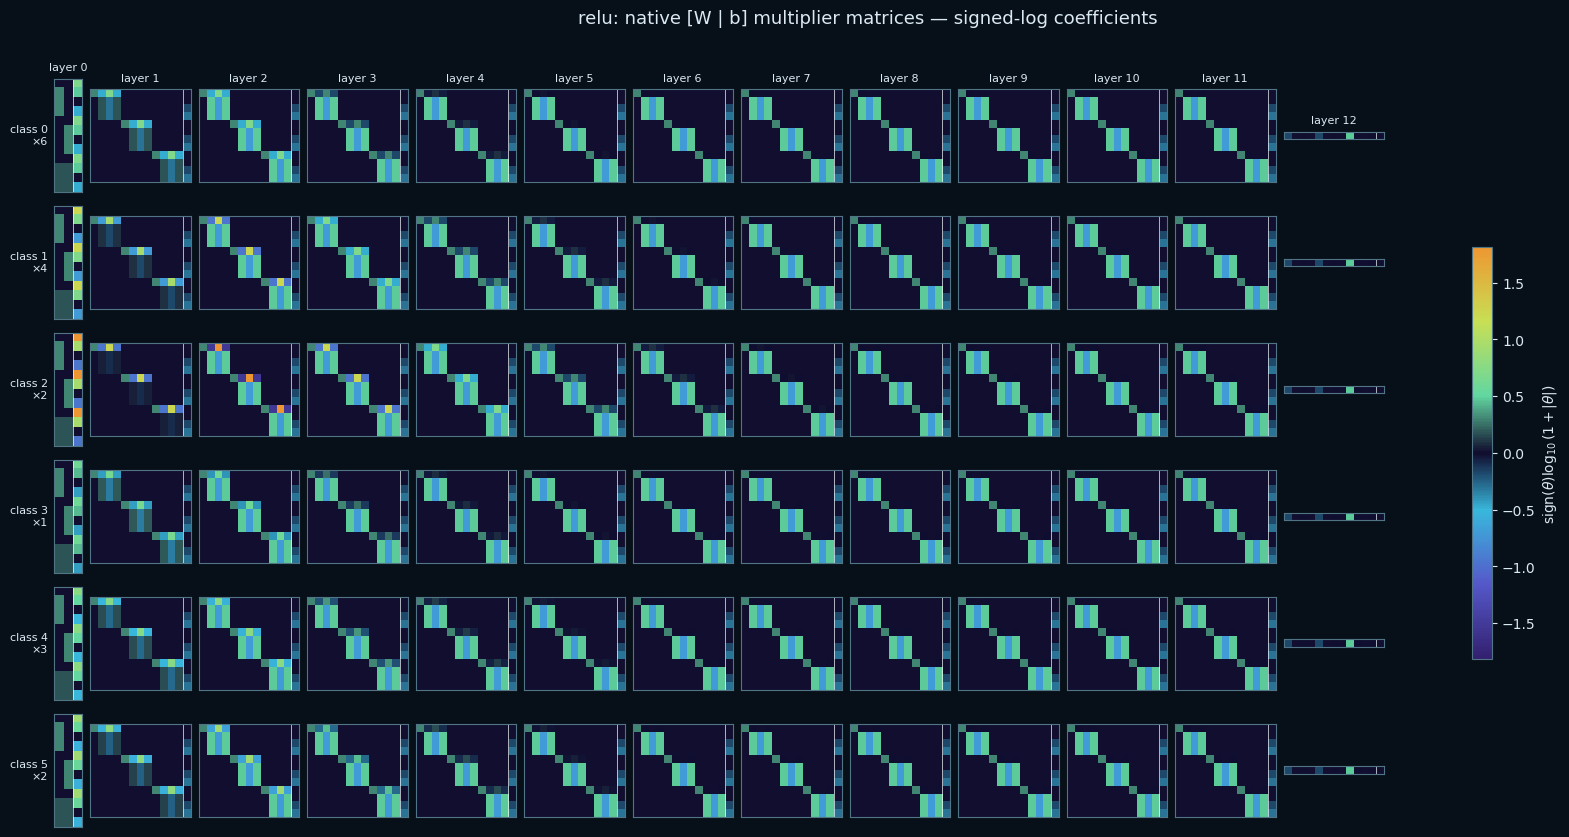

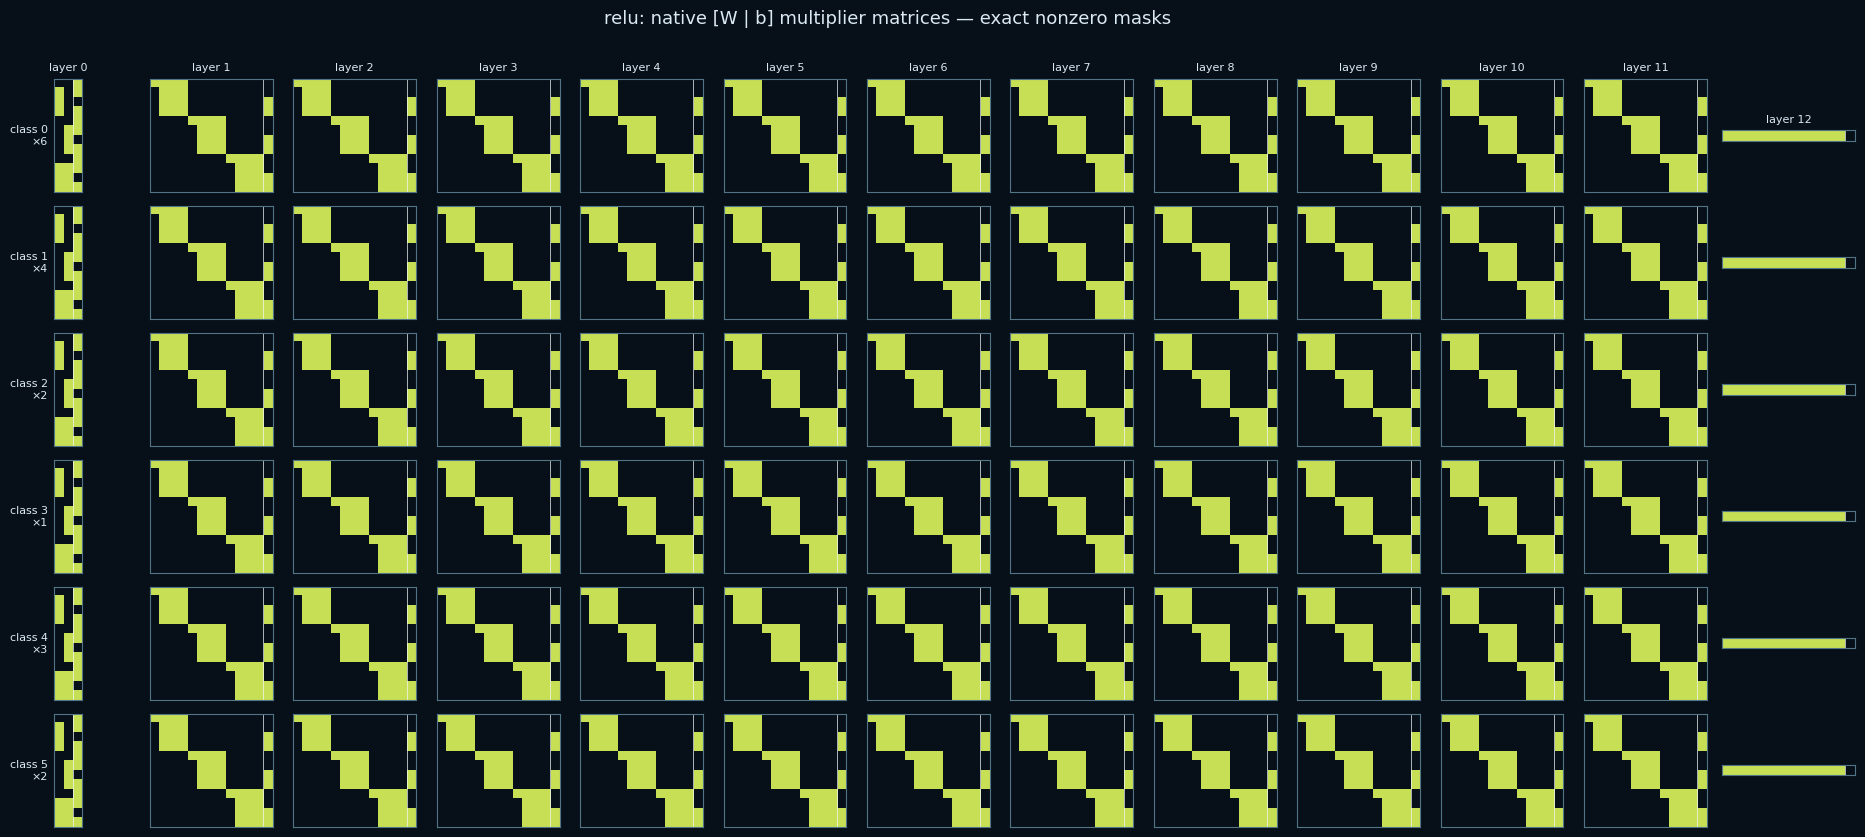

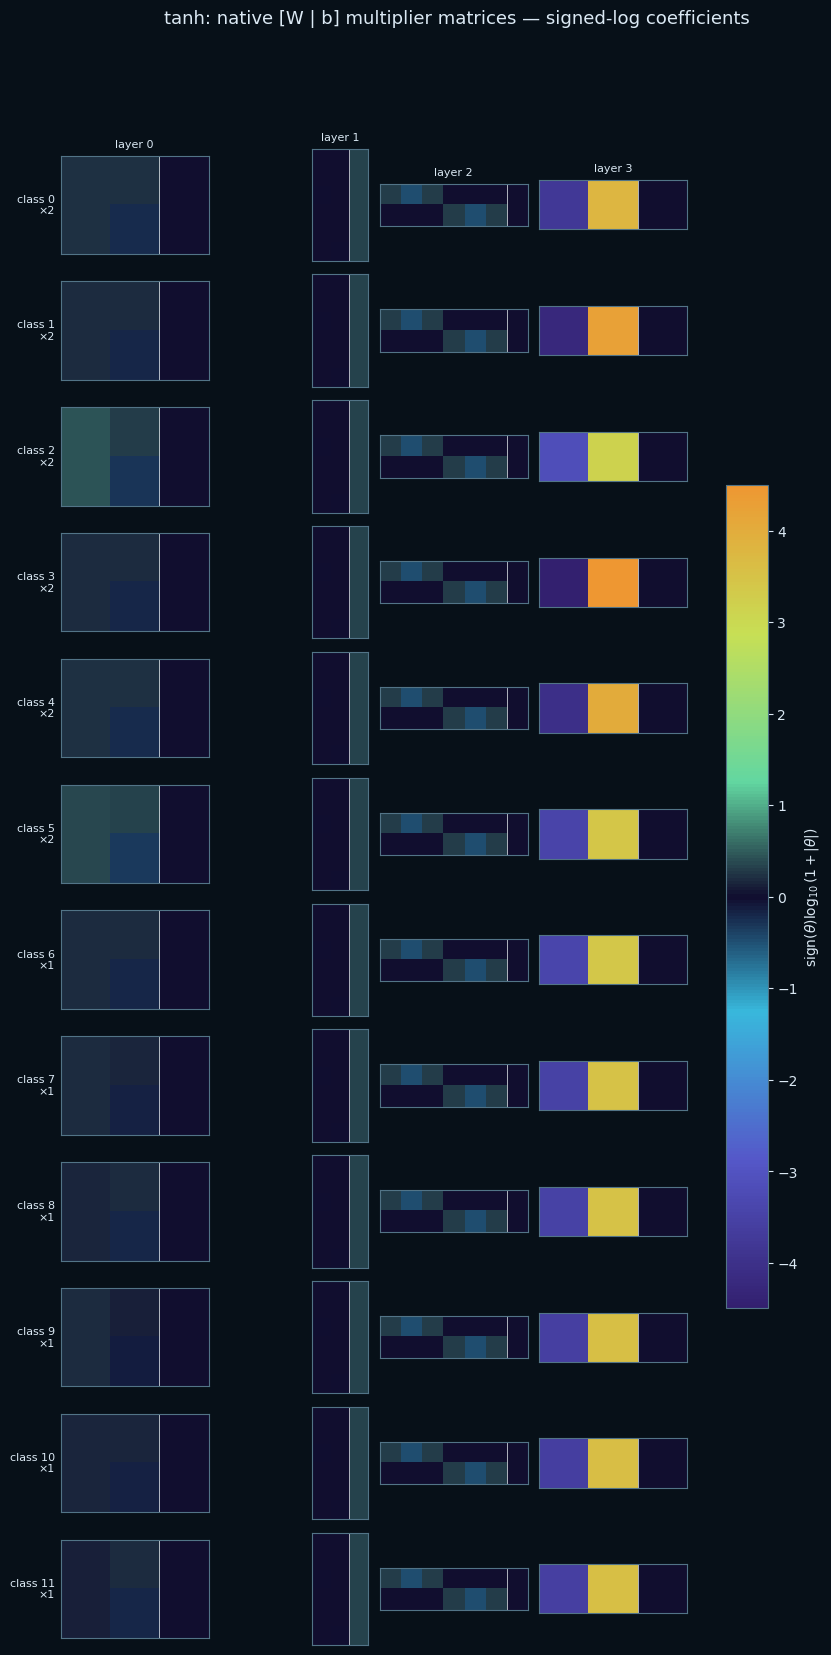

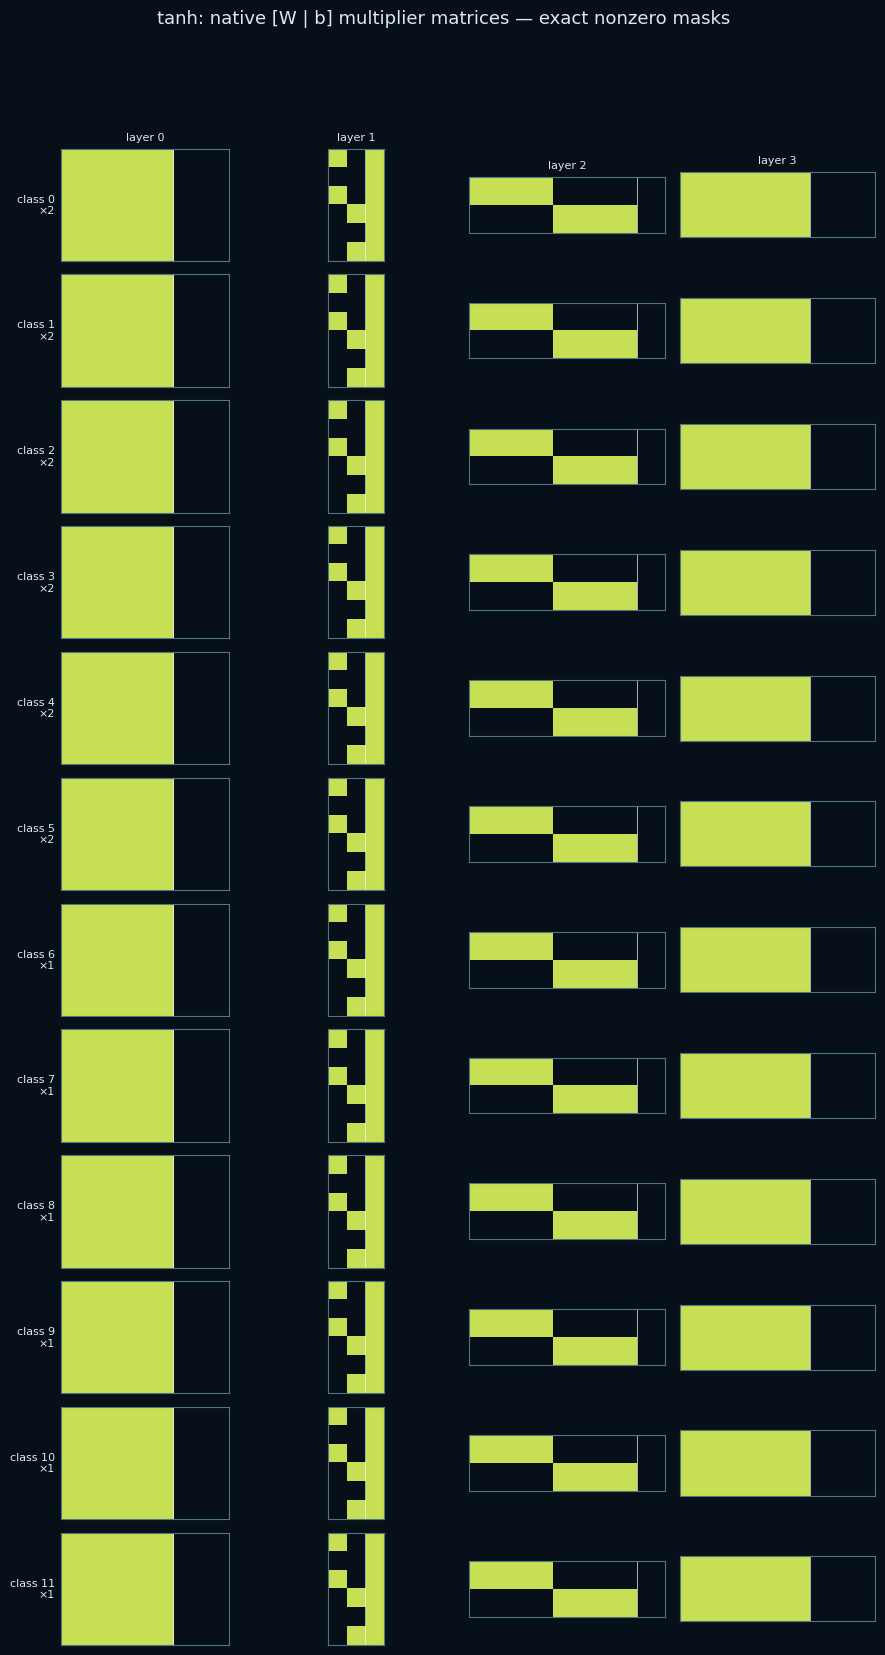

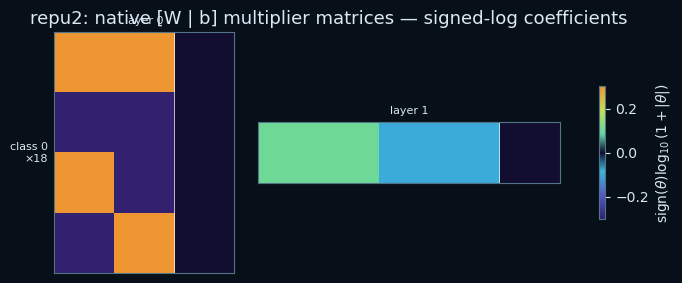

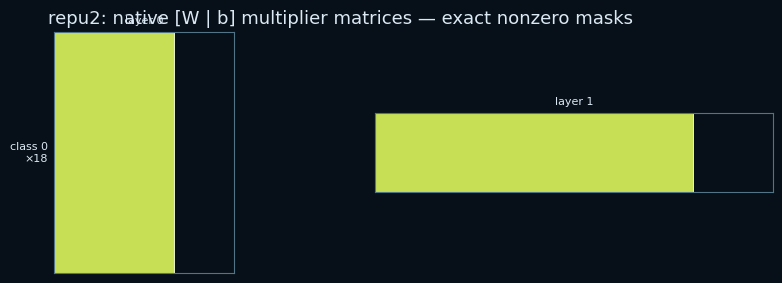

In [4]:
if FLATTEN_AFFINE_LAYERS:
    fig, axes = plt.subplots(len(PRODUCTS), 2, figsize=(18, 12))
    fig.patch.set_facecolor(FIGURE_BACKGROUND)
    coefficient_colormap = parameter_colormap()
    mask_colormap = sparsity_colormap()
    for row, product in enumerate(PRODUCTS):
        records = linear_records(models[product])
        atlas = padded_atlas(records)
        transformed = signed_log(atlas)
        limit = np.nanmax(np.abs(transformed))
        image = axes[row, 0].imshow(
            transformed,
            aspect="auto",
            interpolation="nearest",
            cmap=coefficient_colormap,
            vmin=-limit,
            vmax=limit,
        )
        mask = np.where(np.isnan(atlas), np.nan, atlas != 0.0)
        axes[row, 1].imshow(
            mask, aspect="auto", interpolation="nearest", cmap=mask_colormap
        )
        stride = max(1, len(records) // 18)
        ticks = np.arange(0, len(records), stride)
        labels = [short_name(records[index]["name"]) for index in ticks]
        for ax in axes[row]:
            ax.set_yticks(ticks, labels, fontsize=6)
            ax.set_xlabel("flattened weights, then biases")
            style_inspection_axis(ax)
        axes[row, 0].set_title(f"{product}: signed-log coefficients")
        axes[row, 1].set_title(f"{product}: exact nonzero mask")
        colorbar = fig.colorbar(image, ax=axes[row, 0], fraction=0.02, pad=0.01)
        style_inspection_colorbar(colorbar)
    fig.tight_layout()
    plt.show()
else:
    for product in PRODUCTS:
        plot_native_gallery(product, models[product], nonzero_mask=False)
        plot_native_gallery(product, models[product], nonzero_mask=True)


## Three-dimensional X-ray view

Each translucent plane is one native affine matrix $[W\mid b]$, stacked
along network depth. Cool and warm hues retain the coefficient sign, opacity grows
with signed-log magnitude, and exact zeros are nearly transparent. With the
default inspection-scan palette, negative values run indigo through electric
blue and cyan, while positive values run mint through acid yellow-green to
amber. The pale line marks the boundary before
the bias column. Select one distinct multiplier
class per activation using `XRAY_PARAMETER_CLASSES` near the top; the title
reports how many nodes share that class. Each activation uses its own symmetric
color scale.


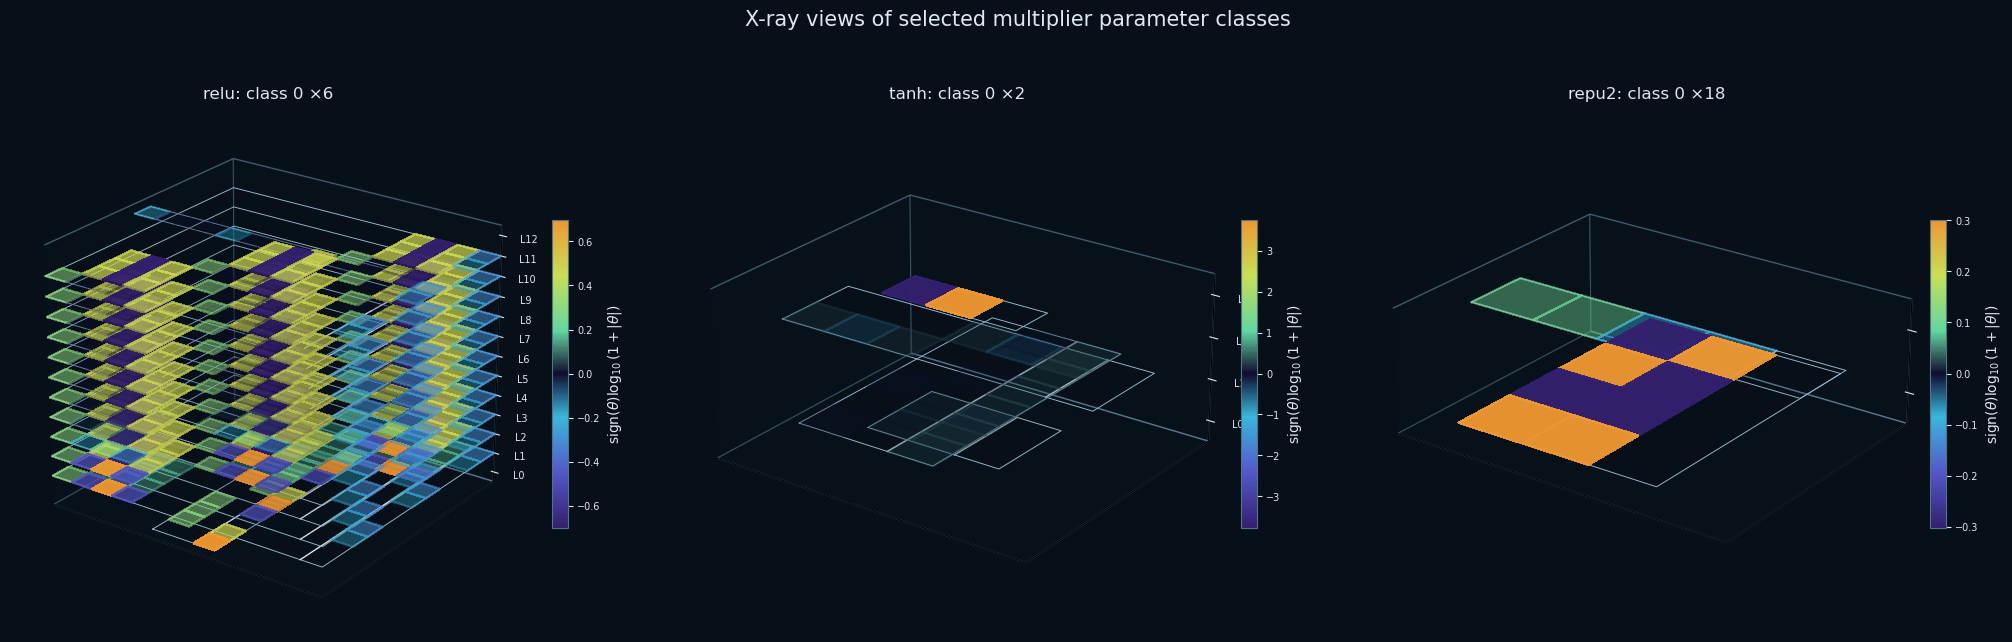

In [5]:
if SHOW_XRAY_3D:
    fig = plt.figure(figsize=(21, 7), facecolor=FIGURE_BACKGROUND)
    fig.subplots_adjust(
        left=0.02, right=0.98, bottom=0.06, top=0.86, wspace=0.08
    )
    for column, product in enumerate(PRODUCTS):
        axis = fig.add_subplot(1, len(PRODUCTS), column + 1, projection="3d")
        mappable = draw_xray(
            axis, product, models[product], XRAY_PARAMETER_CLASSES[product]
        )
        colorbar = fig.colorbar(mappable, ax=axis, shrink=0.55, pad=0.04)
        colorbar.set_label(r"sign$(\theta)\log_{10}(1+|\theta|)$")
        style_inspection_colorbar(colorbar)
        colorbar.ax.tick_params(labelsize=7)
    fig.suptitle(
        "X-ray views of selected multiplier parameter classes",
        color=FIGURE_INK,
        fontsize=15,
    )
    plt.show()


## Representative multiplier matrices

These panels preserve the matrix layout of the first, a middle, and the
last affine layer in one scalar multiplier. The final displayed column is
the bias. ReLU's block-diagonal hidden transitions and the shallow tanh and
RePU-2 structures are visible directly.


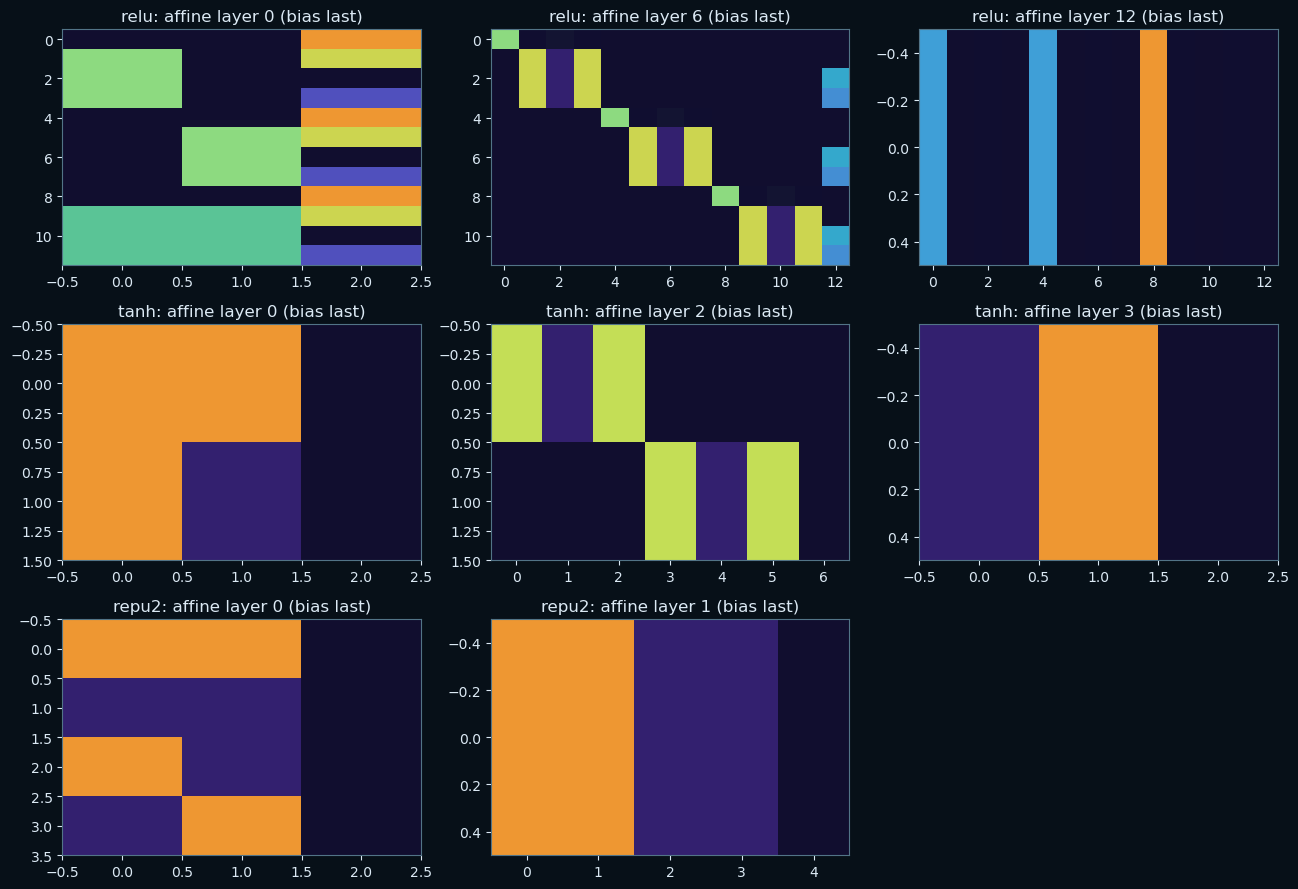

In [6]:
fig, axes = plt.subplots(len(PRODUCTS), 3, figsize=(13, 9))
fig.patch.set_facecolor(FIGURE_BACKGROUND)
coefficient_colormap = parameter_colormap()
for row, product in enumerate(PRODUCTS):
    representative = next(
        module
        for module in models[product].modules()
        if isinstance(module, FeedforwardProductNet)
    )
    layers = [
        module for module in representative.network if isinstance(module, nn.Linear)
    ]
    selected = sorted({0, len(layers) // 2, len(layers) - 1})
    for column, layer_index in enumerate(selected):
        layer = layers[layer_index]
        augmented = np.column_stack(
            (layer.weight.detach().cpu().numpy(), layer.bias.detach().cpu().numpy())
        )
        transformed = signed_log(augmented)
        limit = max(np.max(np.abs(transformed)), 1e-15)
        axes[row, column].imshow(
            transformed,
            aspect="auto",
            interpolation="nearest",
            cmap=coefficient_colormap,
            vmin=-limit,
            vmax=limit,
        )
        axes[row, column].set_title(
            f"{product}: affine layer {layer_index} (bias last)"
        )
        style_inspection_axis(axes[row, column])
    for column in range(len(selected), 3):
        axes[row, column].axis("off")
fig.tight_layout()
plt.show()


## Root-shift biases and output normalizations

For each univariate polynomial node, the root-factor layer has unit input
weights and biases equal to minus the polynomial roots. The last column is
the final normalization weight. Degree-zero rows contain the constant-one
bias instead. Repeated rows arise because each coordinate owns its own basis
sequence.


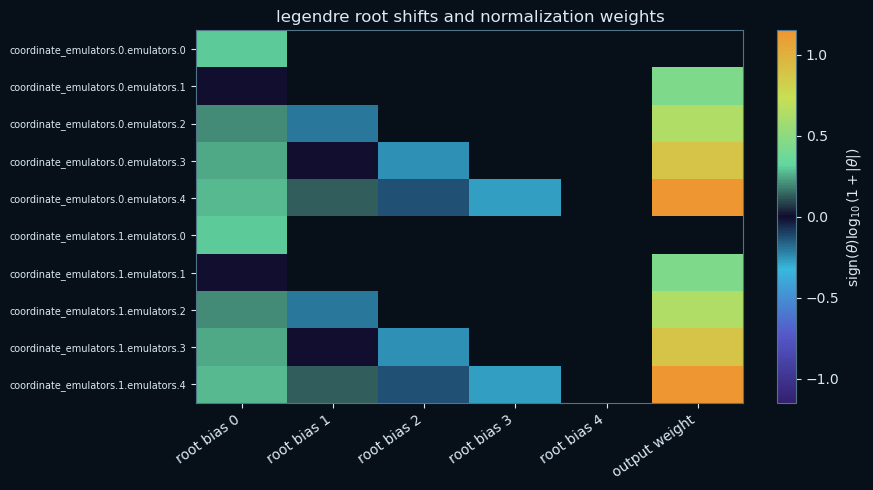

In [7]:
model = models[PRODUCTS[0]]
root_rows = []
root_names = []
for name, module in model.named_modules():
    if not hasattr(module, "degree") or not hasattr(module, "roots"):
        continue
    row = np.full(ORDER + 2, np.nan)
    if module.degree == 0:
        row[0] = 1.0
    else:
        biases = module.feedforward_factor_layer.bias.detach().cpu().numpy()
        row[: module.degree] = biases
        row[-1] = float(module.feedforward_output_layer.weight.item())
    root_rows.append(row)
    root_names.append(short_name(name, limit=58))
root_atlas = np.stack(root_rows)
transformed = signed_log(root_atlas)
limit = np.nanmax(np.abs(transformed))
fig, ax = plt.subplots(figsize=(9, max(5, 0.28 * len(root_rows))))
fig.patch.set_facecolor(FIGURE_BACKGROUND)
image = ax.imshow(
    transformed,
    aspect="auto",
    interpolation="nearest",
    cmap=parameter_colormap(),
    vmin=-limit,
    vmax=limit,
)
ax.set_yticks(np.arange(len(root_names)), root_names, fontsize=7)
ax.set_xticks(
    np.arange(ORDER + 2),
    [*[f"root bias {index}" for index in range(ORDER + 1)], "output weight"],
    rotation=35,
    ha="right",
)
ax.set_title(f"{FAMILY} root shifts and normalization weights")
style_inspection_axis(ax)
colorbar = fig.colorbar(
    image, ax=ax, label=r"sign$(\theta)\log_{10}(1+|\theta|)$"
)
style_inspection_colorbar(colorbar)
fig.tight_layout()
plt.show()


The nonzero masks distinguish architectural sparsity from small numerical
coefficients. The signed-log views expose repeated blocks, scale separation,
root symmetry, and possible parameter sharing. Change `FAMILY`, `DIMENSION`,
`ORDER`, or `INDEX_SET_TYPE` above to examine how these patterns change.
